Q1: Dataset loaded successfully.

------------------------------

Q2: First 5 records:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2

Last 5 records:
     sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
145                6.7               3.0                5.2               2.3
146                6.3               2.5                5.0               1.9
147                6.5               3.0                5.2               2.0
148                6.2               3.4                5.4               2.3
149                5.9               3.0          

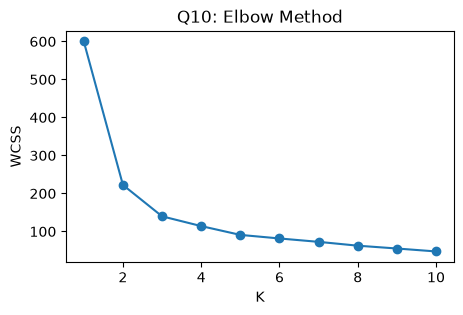

Q11: Plotting K-Means Clusters...


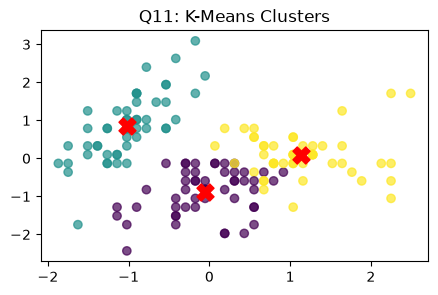

Q12: Cluster Centroids:
[[-0.05021989 -0.88337647  0.34773781  0.2815273 ]
 [-1.01457897  0.85326268 -1.30498732 -1.25489349]
 [ 1.13597027  0.08842168  0.99615451  1.01752612]]

------------------------------

Q14: Comparison (Scaled vs Unscaled):
col_0   0   1   2
row_0            
0      52   0  10
1       0  50   0
2       1   0  37

------------------------------

Q16: Displaying Dendrogram...


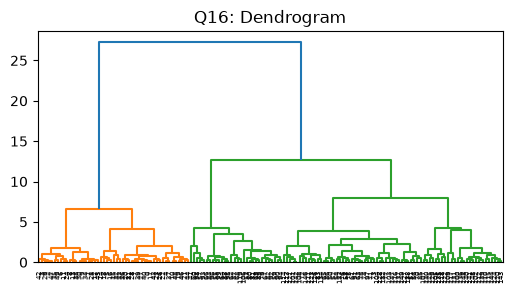

Q19: Ward vs Complete Linkage Comparison:
col_0   0   1   2
row_0            
0      71   0   0
1       0  49   0
2       6   0  24

------------------------------

Q20: Displaying Hierarchical Clustering plot...


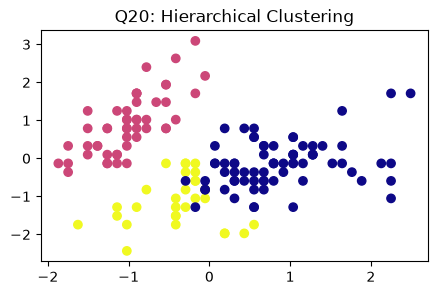

Q21: K-Means vs Hierarchical:
col_0   0   1   2
row_0            
0      24   0  29
1       0  49   1
2      47   0   0

------------------------------

Q24: Displaying 2D PCA plot...


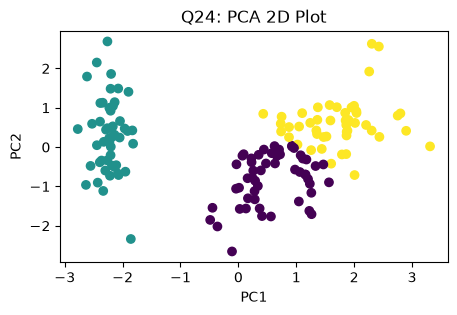

Q25: Explained variance ratio: [0.72962445 0.22850762]
Q26: Cumulative variance: 0.9581320720000163
Q27: Shape before PCA: (150, 4) | Shape after PCA: (150, 2)

------------------------------

Q29: Silhouette score before PCA: 0.45994823920518646
Silhouette score after PCA: 0.5091683341538228

------------------------------

Q31: Silhouette scores for different K values:
K = 2: Score = 0.5817500491982808
K = 3: Score = 0.45994823920518646
K = 4: Score = 0.38694104154427816
K = 5: Score = 0.3459012795948778

------------------------------

Q32: Cluster means:
         sepal length (cm)  sepal width (cm)  petal length (cm)  \
Cluster                                                           
0                 5.801887          2.673585           4.369811   
1                 5.006000          3.428000           1.462000   
2                 6.780851          3.095745           5.510638   

         petal width (cm)  
Cluster                    
0                1.413208  
1              

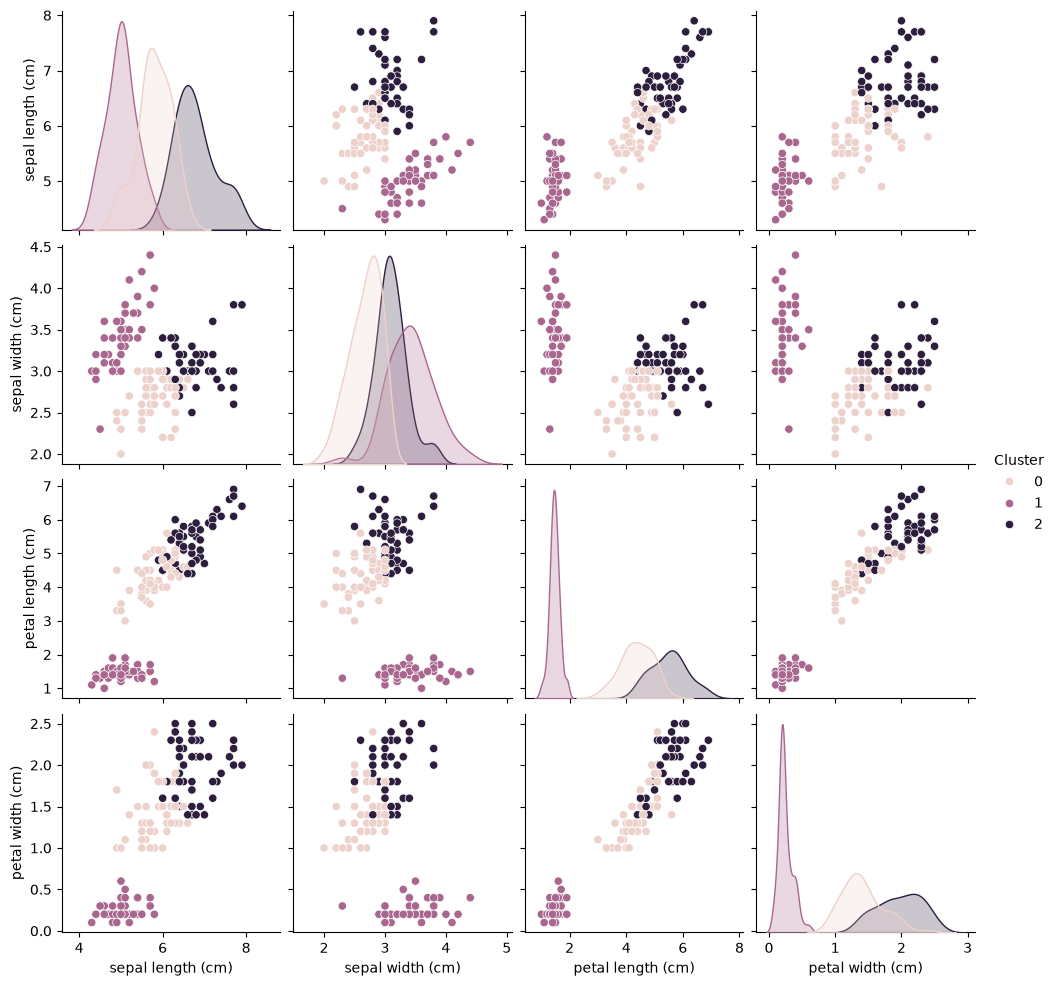

Q34: Saved to 'clustered_output.csv'
Q35: K-Means and Hierarchical Clustering both give similar results on scaled Iris data.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import scipy.cluster.hierarchy as sch

# Q1
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
print("Q1: Dataset loaded successfully.")
print("\n" + "-"*30 + "\n")

# Q2
print("Q2: First 5 records:")
print(df.head(5))
print("\nLast 5 records:")
print(df.tail(5))
print("\n" + "-"*30 + "\n")

# Q3
print("Q3: Info & Stats:")
df.info()
print(df.describe())
print("\n" + "-"*30 + "\n")

# Q4 & Q5
X = df.copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("Q4 & Q5: Standardized features sample:")
print(X_scaled[:5])
print("\n" + "-"*30 + "\n")

# Q6 & Q7
kmeans_k2 = KMeans(n_clusters=2, random_state=42, n_init=10)
labels_k2 = kmeans_k2.fit_predict(X_scaled)
print("Q6 & Q7: K-Means with K=2 done.")

# Q8
kmeans_k3 = KMeans(n_clusters=3, random_state=42, n_init=10)
labels_k3 = kmeans_k3.fit_predict(X_scaled)
print("Q8: K-Means with K=3 done.")
print("\n" + "-"*30 + "\n")

# Q9 & Q10
wcss = []
for k in range(1, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    wcss.append(km.inertia_)

print("Q10: Plotting Elbow Method...")
plt.figure(figsize=(5, 3))
plt.plot(range(1, 11), wcss, marker='o')
plt.title("Q10: Elbow Method")
plt.xlabel("K")
plt.ylabel("WCSS")
plt.show()

# Q11 & Q12
print("Q11: Plotting K-Means Clusters...")
plt.figure(figsize=(5, 3))
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=labels_k3, cmap='viridis', alpha=0.7)
plt.scatter(kmeans_k3.cluster_centers_[:, 0], kmeans_k3.cluster_centers_[:, 1], s=150, c='red', marker='X')
plt.title("Q11: K-Means Clusters")
plt.show()

print("Q12: Cluster Centroids:")
print(kmeans_k3.cluster_centers_)
print("\n" + "-"*30 + "\n")

# Q13 & Q14
df_clustered = df.copy()
df_clustered['Cluster'] = labels_k3

kmeans_unscaled = KMeans(n_clusters=3, random_state=42, n_init=10)
unscaled_labels = kmeans_unscaled.fit_predict(X)
print("Q14: Comparison (Scaled vs Unscaled):")
print(pd.crosstab(unscaled_labels, labels_k3))
print("\n" + "-"*30 + "\n")

# Q15 & Q16
print("Q16: Displaying Dendrogram...")
plt.figure(figsize=(6, 3))
sch.dendrogram(sch.linkage(X_scaled, method='ward'))
plt.title("Q16: Dendrogram")
plt.show()

# Q17, Q18, Q19
hc_ward = AgglomerativeClustering(n_clusters=3, linkage='ward')
ward_labels = hc_ward.fit_predict(X_scaled)

hc_comp = AgglomerativeClustering(n_clusters=3, linkage='complete')
comp_labels = hc_comp.fit_predict(X_scaled)

print("Q19: Ward vs Complete Linkage Comparison:")
print(pd.crosstab(ward_labels, comp_labels))
print("\n" + "-"*30 + "\n")

# Q20 & Q21
print("Q20: Displaying Hierarchical Clustering plot...")
plt.figure(figsize=(5, 3))
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=ward_labels, cmap='plasma')
plt.title("Q20: Hierarchical Clustering")
plt.show()

print("Q21: K-Means vs Hierarchical:")
print(pd.crosstab(labels_k3, ward_labels))
print("\n" + "-"*30 + "\n")

# Q22, Q23, Q24
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print("Q24: Displaying 2D PCA plot...")
plt.figure(figsize=(5, 3))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels_k3, cmap='viridis')
plt.title("Q24: PCA 2D Plot")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

# Q25, Q26, Q27
print("Q25: Explained variance ratio:", pca.explained_variance_ratio_)
print("Q26: Cumulative variance:", np.sum(pca.explained_variance_ratio_))
print("Q27: Shape before PCA:", X_scaled.shape, "| Shape after PCA:", X_pca.shape)
print("\n" + "-"*30 + "\n")

# Q28 & Q29
kmeans_pca = KMeans(n_clusters=3, random_state=42, n_init=10)
pca_labels = kmeans_pca.fit_predict(X_pca)

score_before = silhouette_score(X_scaled, labels_k3)
score_after = silhouette_score(X_pca, pca_labels)
print("Q29: Silhouette score before PCA:", score_before)
print("Silhouette score after PCA:", score_after)
print("\n" + "-"*30 + "\n")

# Q30 & Q31
print("Q31: Silhouette scores for different K values:")
for k in range(2, 6):
    km_temp = KMeans(n_clusters=k, random_state=42, n_init=10)
    l_temp = km_temp.fit_predict(X_scaled)
    print(f"K = {k}: Score = {silhouette_score(X_scaled, l_temp)}")
print("\n" + "-"*30 + "\n")

# Q32
print("Q32: Cluster means:")
print(df_clustered.groupby('Cluster').mean())
print("\n" + "-"*30 + "\n")

# Q33
print("Q33: Displaying Pairplot...")
sns.pairplot(df_clustered, hue='Cluster')
plt.show()

# Q34 & Q35
df_clustered.to_csv("clustered_output.csv", index=False)
print("Q34: Saved to 'clustered_output.csv'")
print("Q35: K-Means and Hierarchical Clustering both give similar results on scaled Iris data.")